# Spam And Ham Classification

### 1 Problem statement
- Given a dataset of emails, determine whether each email is "spam" or "not spam."
- This is a binary classification problem, where:
  + Input: Email text
  + Output: Spam (1) or Ham (0)

### 2 Data collection
- Dataset Source - https://www.kaggle.com/datasets/zubairmustafa/spam-and-ham-classification-balanced-dataset/data from Kaggle
- It contains: 
  + text: the content of the email
  + label: indicates whether the email is spam or ham

#### 2.1 Import data and Required Packages

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")  # ẩn các cảnh báo

In [3]:
df = pd.read_csv("spam_and_ham_classification.csv")

In [4]:
df.head()

,label,text
0,ham,into the kingdom of god and those that are ent...
1,spam,there was flow at hpl meter 1505 on april firs...
2,ham,take a look at this one campaign for bvyhprice...
3,spam,somu wrote actually thats what i was looking f...
4,spam,fathi boudra wrote i fixed the issue in the sv...


In [5]:
df.shape

(9989, 2)

### 3. Data checks to perform
Before training the model, several checks are performed:
- Check for missing value
- Check duplicate entries
- Verify data types
- Check class dítribution (spam vs ham)

In [6]:
df.isnull().sum()

label    0
text     0
dtype: int64

- There are no missing value in the dataset

In [7]:
df.duplicated().sum()

np.int64(0)

- There are no duplicate rows in the dataset

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9989 entries, 0 to 9988
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   label   9989 non-null   str  
 1   text    9989 non-null   str  
dtypes: str(2)
memory usage: 156.2 KB


In [9]:
df.describe()

,label,text
count,9989,9989
unique,2,9989
top,ham,into the kingdom of god and those that are ent...
freq,5294,1


- Only spam and ham
- The class that appears most often is ham
- The amount of ham is greater than spam

In [10]:
df['label'].value_counts()

label
ham     5294
spam    4695
Name: count, dtype: int64

- The dataset is quite balanced
   + ham 53%
   + spam 47%
   -> no problem imbalanced data

### 4. Feature engineering

In [11]:
# Text length
df["text_length"] = df['text'].apply(len)

# Number of words
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

# Number of special characters (! ? $)
df['special_char_count'] = df['text'].apply(lambda x: sum(1 for c in x if not c.isalnum()))

# Number of uppercase letters
df['uppercase_count'] = df['text'].apply(lambda x: sum(1 for c in x if c.isupper()))

# Keyword features
spam_keys = ['free', 'thats', 'money', 'offer', 'click']

for key in spam_keys:
    df[f'{key}'] = df['text'].apply(lambda x: x.lower().count(key))

### 5. Visualization

#### 5.1 Distribution of Spam with Ham

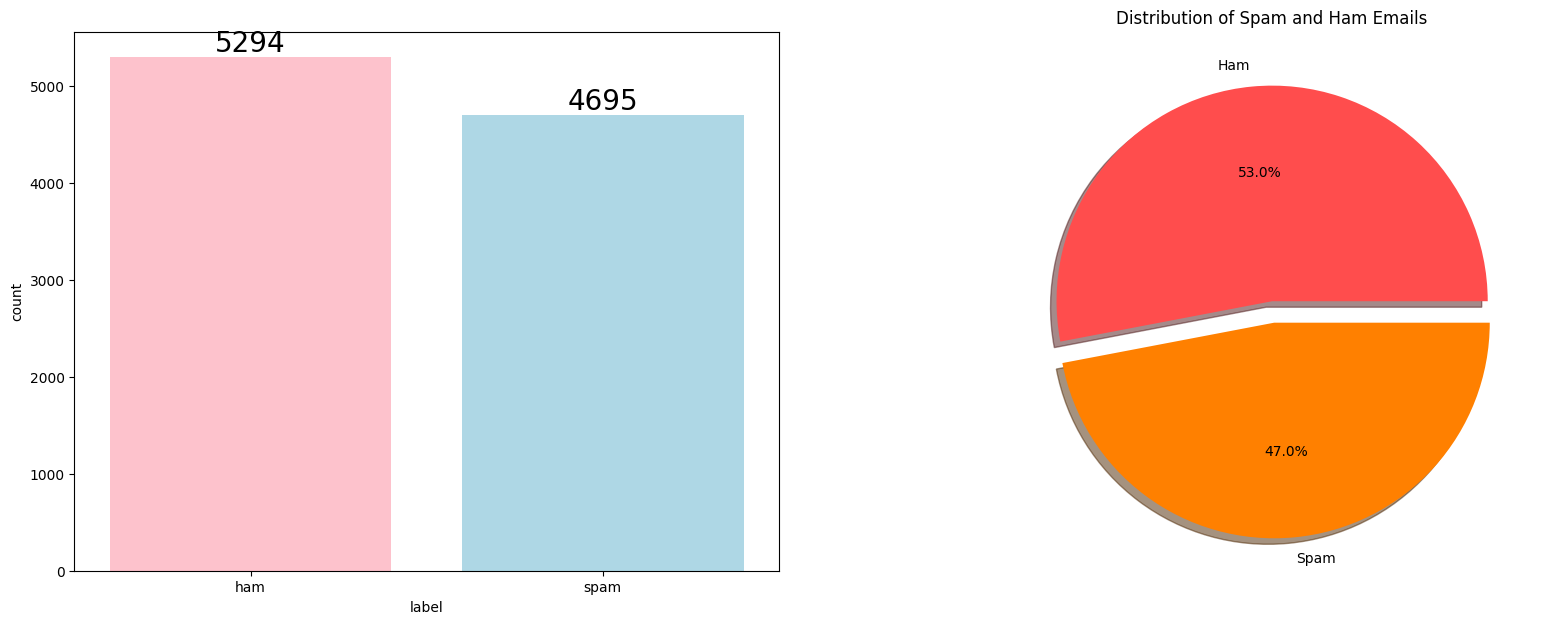

In [12]:
f, ax = plt.subplots(1,2, figsize=(20,7))
color = ["pink", "lightblue"]
sns.countplot(x='label', data=df, palette = color, ax=ax[0], saturation=0.95)
for container in ax[0].containers:
    ax[0].bar_label(container, color='black', size=20)
plt.pie(x = df['label'].value_counts(), labels=['Ham', 'Spam'], explode=[0, 0.1], autopct='%1.1f%%',shadow=True,colors=['#ff4d4d','#ff8000'] )
plt.title("Distribution of Spam and Ham Emails")
plt.show()

- Quantity of ham ≈ spam
- Balanced data set → model learns well, no bias

#### 5.3 Text length (spam vs ham)

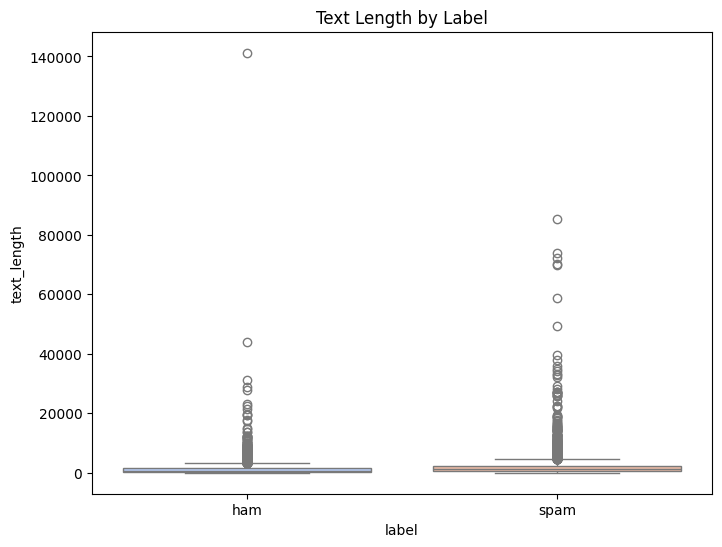

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(x='label', y='text_length', data=df, palette='coolwarm')
plt.title("Text Length by Label")
plt.show()

- Spam often tends to: longer or more special characters
- Ham is often more natural

#### 5.4 Word Count Distribution

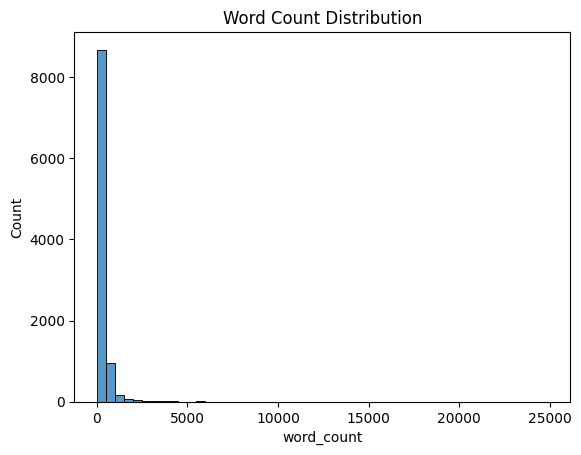

In [14]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

sns.histplot(df['word_count'], bins=50)
plt.title("Word Count Distribution")
plt.show()

#### 5.5 Top words

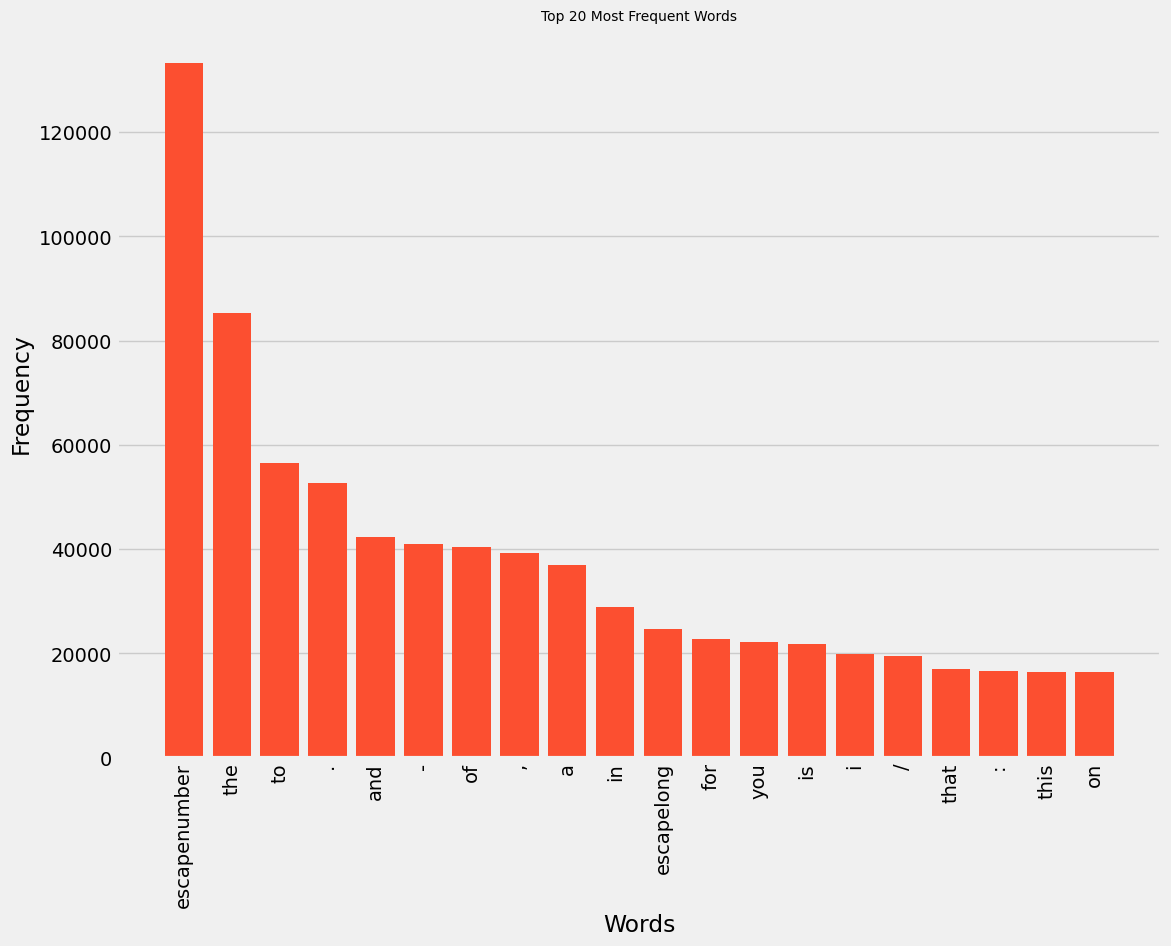

In [15]:
from collections import Counter

# Merge all text
all_words = ' '.join(df['text']).lower().split()

# Count word frequencies
word_freq = Counter(all_words)

# Get the 20 most common words
common_words = word_freq.most_common(20)

# Seperate words and counts
words = [w[0] for w in common_words]
counts = [w[1] for w in common_words]

# Plot
plt.rcParams['figure.figsize'] = (12,9)
plt.style.use('fivethirtyeight')
sns.barplot(x=words, y=counts, palette='Blues_d')
plt.title("Top 20 Most Frequent Words", fontweight=11, fontsize=10)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.bar(words, counts)
plt.show()

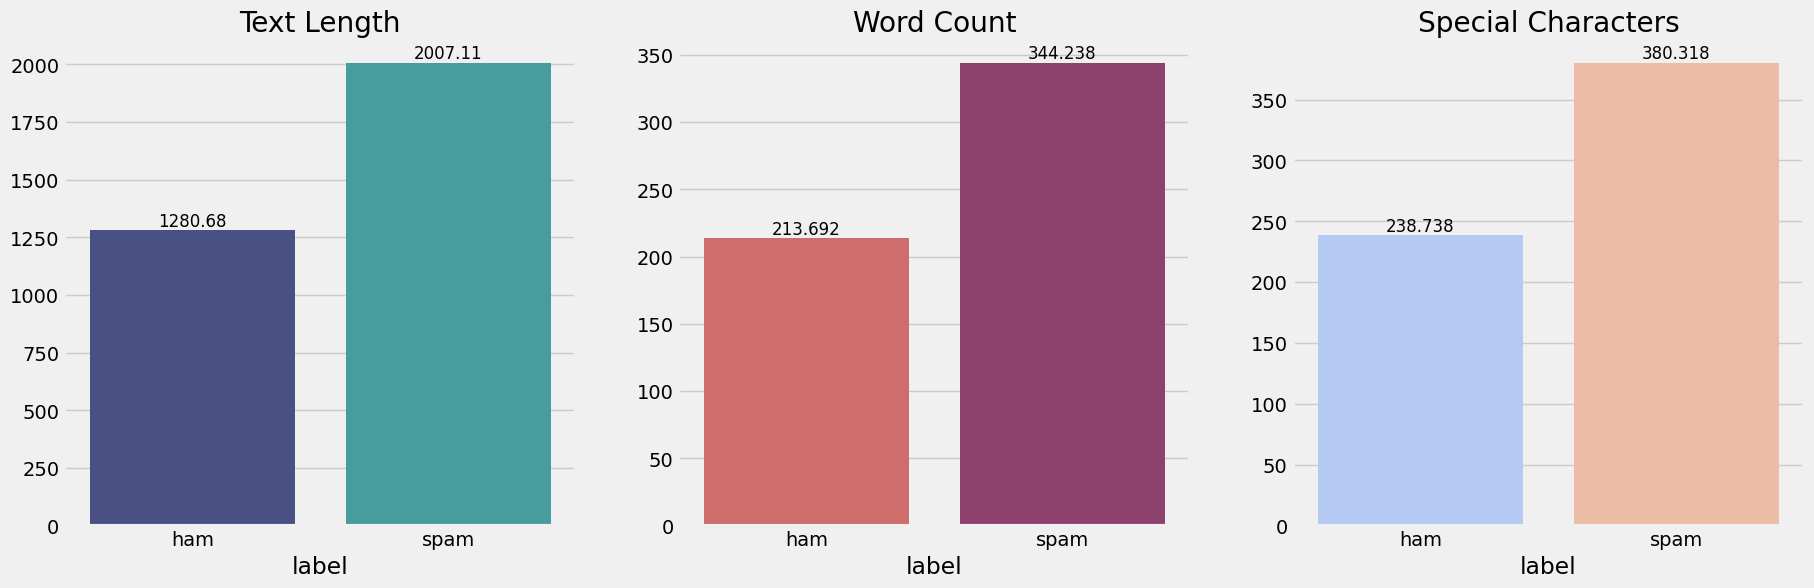

In [16]:
group_data = df.groupby('label')

f, ax = plt.subplots(1,3,figsize=(20,6))

# Text length
sns.barplot(x=group_data['text_length'].mean().index,
            y=group_data['text_length'].mean().values,
            palette='mako', ax=ax[0])
ax[0].set_title('Text Length')

# Word count
sns.barplot(x=group_data['word_count'].mean().index,
            y=group_data['word_count'].mean().values,
            palette='flare', ax=ax[1])
ax[1].set_title('Word Count')

# Special chars
sns.barplot(x=group_data['special_char_count'].mean().index,
            y=group_data['special_char_count'].mean().values,
            palette='coolwarm', ax=ax[2])
ax[2].set_title('Special Characters')

# label value trên cột
for i in range(3):
    for container in ax[i].containers:
        ax[i].bar_label(container, size=12)

plt.show()
plt.close()

### Conclusion

- The dataset is balanced and contains diverse text data with minimal duplication
- The distributions of text length and word count are right-skewed with some outliers.
- Word frequency analysis shows clear differences between spam and ham emails. 
- Therefore, TF-IDF is an appropriate method for feature extraction

### 6. Data Preprocessing
- Data preprocessing is performed to clean and transform raw text data into a suitable format for model training.

In [17]:
# Convert all text to lowercase to ưnsure consistency
df['text'] = df['text'].str.lower()

# Remove punctuation
import string

df['text'] = df['text'].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

# Remove Stopwords
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

df['text'] = df['text'].apply(
    lambda x: ' '.join([word for word in x.split() if word not in ENGLISH_STOP_WORDS])
)

In [18]:
# Tokenization
df['tokens'] = df['text'].apply(lambda x: x.split())

# Label encoding
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

##### Split data and TF-IDF

In [19]:
# Split
from sklearn.model_selection import train_test_split

X = df['text']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

### 7. Model Training

##### Logistic Regression

In [ ]:
class LogisticRegressionS:
    def __init__(self, learning_rate=0.01, n_iterations=200):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []
    
    def sigmoid(self, z):
        return 1/(1 + np.exp(-np.clip(z, -250, 250)))  # Clip to avoid overflow
    
    def binary_cross_entropy_loss(self, y_true, y_pred):
        epsilon = 1e-15
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

    def fit(self, X, y):
        n_samples, n_features = X.shape  # Fix typo: n_spamles -> n_samples

        self.weights = np.zeros(n_features)
        self.bias = 0
        self.loss_history = []

        # Gradient descent
        for iteration in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = self.sigmoid(linear_model)

            loss = self.binary_cross_entropy_loss(y, y_pred)
            self.loss_history.append(loss)

            dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
            db = (1/n_samples) * np.sum(y_pred - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            if iteration % 100 == 0:
                print(f"Iteration {iteration}, Loss: {loss:.4f}")
    
    def predict_label(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        y_pred = self.sigmoid(linear_model)
        return (y_pred >= 0.5).astype(int)
    
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self.sigmoid(linear_model)

In [22]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [28]:
model = LogisticRegressionS(learning_rate=0.01, n_iterations=2000)
model.fit(X_train_tfidf.toarray(), y_train)

Iteration 0, Loss: 0.6931
Iteration 100, Loss: 0.6909
Iteration 200, Loss: 0.6888
Iteration 300, Loss: 0.6870
Iteration 400, Loss: 0.6852
Iteration 500, Loss: 0.6836
Iteration 600, Loss: 0.6819
Iteration 700, Loss: 0.6803
Iteration 800, Loss: 0.6787
Iteration 900, Loss: 0.6771
Iteration 1000, Loss: 0.6756
Iteration 1100, Loss: 0.6740
Iteration 1200, Loss: 0.6725
Iteration 1300, Loss: 0.6710
Iteration 1400, Loss: 0.6694
Iteration 1500, Loss: 0.6679
Iteration 1600, Loss: 0.6664
Iteration 1700, Loss: 0.6650
Iteration 1800, Loss: 0.6635
Iteration 1900, Loss: 0.6620


In [24]:
# Dự đoán nhãn trên tập test
y_pred = model.predict_label(X_test_tfidf.toarray())

Accuracy: 0.9790
Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      1058
           1       0.98      0.97      0.98       940

    accuracy                           0.98      1998
   macro avg       0.98      0.98      0.98      1998
weighted avg       0.98      0.98      0.98      1998



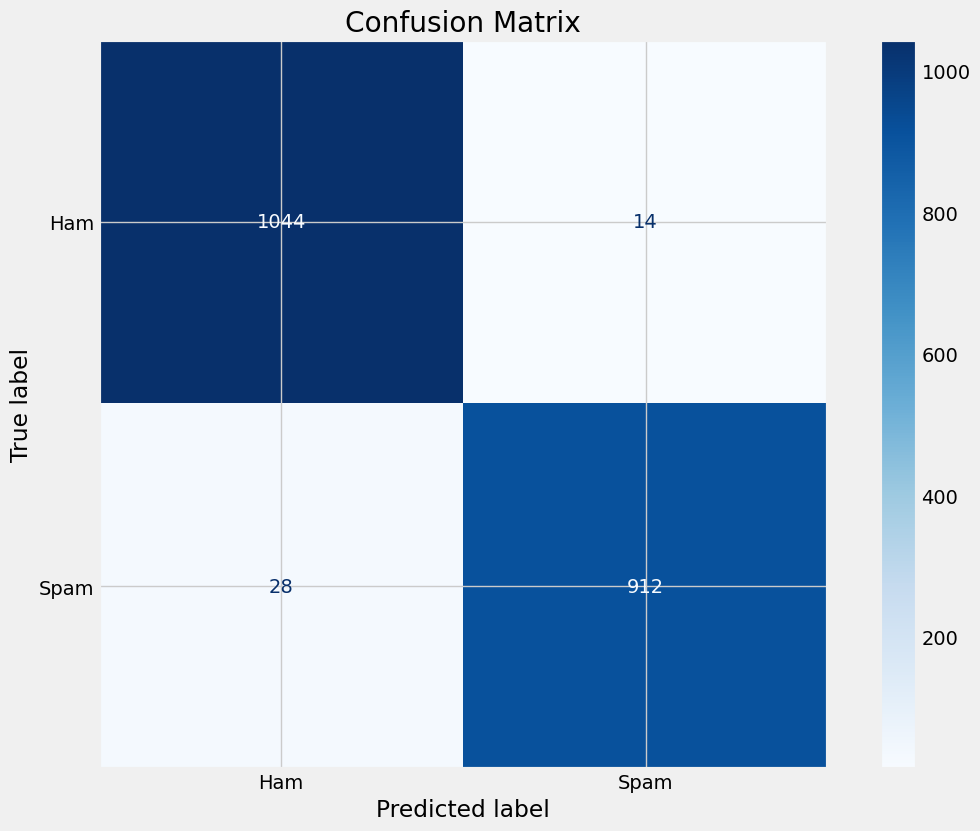

In [29]:
# Đánh giá
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Ham', 'Spam'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

##### Insight:
- The Logistic Regression model achieved an accuracy of 97.9%, indicating very strong performance on the test set.
- 1044 ham emails were correctly classified.
- Only 14 ham emails were incorrectly predicted as spam
- 912 spam emails were correctly classified.
- Only 28 spam emails were incorrectly predicted as ham.

<function matplotlib.pyplot.show(close=None, block=None)>

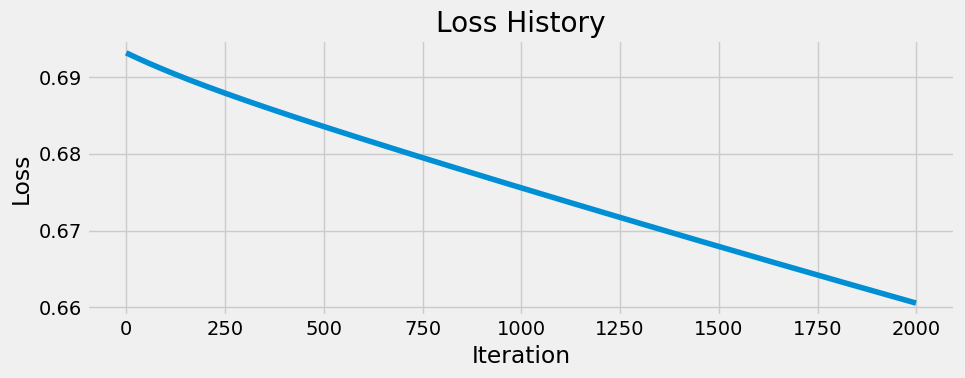

In [30]:
# Plot loss history
plt.figure(figsize=(10,4))
plt.plot(model.loss_history)
plt.title('Loss History')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.grid(True)

plt.tight_layout()
plt.show

- Loss decreases continuously → gradient descent works properly
- No sigmoid/gradient errors 
 -> Model train fine
- After 2000 iterations there is still ~0.66
- No deep reduction (usually can go down to ~0.2–0.4 with this exercise)